<a href="https://colab.research.google.com/github/Ronglawan/AI-in-Financial-Reporting-and-Fraud-Detection/blob/main/AI_in_Financial_Reporting_and_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing and Feature Engineering

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

file_name = "/content/drive/MyDrive/AI in Financial Reporting and Fraud Detection/Synthetic_Financial_datasets_log.csv"

# 1. โหลดข้อมูลดิบ
df = pd.read_csv(file_name)
print(f"--- โหลดข้อมูลดิบจาก Google Drive เรียบร้อย ---")
print(f"จำนวนข้อมูลเริ่มต้น: {df.shape[0]:,} แถว | {df.shape[1]} คอลัมน์")

# ลบข้อมูลที่ไม่มีเฉลยออก
df = df.dropna(subset=['isFraud'])

# =========================================================================
# 🌟 เพิ่มเติม: สกัดฟีเจอร์พฤติกรรมเชิงเวลาและบัญชีปลายทางก่อนดร็อปทิ้ง
# =========================================================================
df['hour_of_day'] = df['step'] % 24
df['day_of_week'] = ((df['step'] // 24) % 7) + 1
df['is_dest_merchant'] = df['nameDest'].str.startswith('M').astype(int)
# =========================================================================

# 2. แยก Target และ Features ตามหลัก Data Privacy
X = df.drop(columns=['isFraud', 'isFlaggedFraud'], errors='ignore')
y = df['isFraud']

# ลบคอลัมน์ยอดเงินคงเหลือ และตัวแปรดิบที่สกัดฟีเจอร์เสร็จแล้วออก
columns_to_drop = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'step', 'nameOrig', 'nameDest']
X = X.drop(columns=columns_to_drop, errors='ignore')

# 3. แปลงประเภทธุรกรรมเป็นตัวเลข และแบ่งข้อมูล (Train 80% / Test 20%)
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. ปรับสเกลข้อมูลมาตรฐาน
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# สรุปสถานะข้อมูลฉบับสมบูรณ์แบบที่คุณต้องการให้แสดงผล
print("\n--- สรุปสถานะข้อมูลหลังแก้ไขรอบนี้ (เวอร์ชันสมบูรณ์) ---")
print(f"Train set (ข้อมูลสมบูรณ์) = {X_train_scaled.shape[0]:,} แถว")
print(f"Test set (ข้อมูลสมบูรณ์)  = {X_test_scaled.shape[0]:,} แถว")
print(f"จำนวนฟีเจอร์ทั้งหมดที่ AI ใช้ตรวจจับ: {X_train_scaled.shape[1]} ฟีเจอร์")

--- โหลดข้อมูลดิบจาก Google Drive เรียบร้อย ---
จำนวนข้อมูลเริ่มต้น: 6,362,620 แถว | 11 คอลัมน์

--- สรุปสถานะข้อมูลหลังแก้ไขรอบนี้ (เวอร์ชันสมบูรณ์) ---
Train set (ข้อมูลสมบูรณ์) = 5,090,096 แถว
Test set (ข้อมูลสมบูรณ์)  = 1,272,524 แถว
จำนวนฟีเจอร์ทั้งหมดที่ AI ใช้ตรวจจับ: 8 ฟีเจอร์


# Model Training and Performance Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# 1. คำนวณน้ำหนักคลาสแก้ปัญหาข้อมูลไม่สมดุล (Class Imbalance)
weight_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# 2. นิยามโมเดลทั้ง 4 ตัวสำหรับทำ Comparative Analysis
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=weight_ratio, random_state=42, n_jobs=-1)
}

results_list = []

# 3. เริ่มเทรนโมเดลและเก็บสถิติวัดผลแบบเจาะลึก
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)

    # บันทึกคะแนนลงสถิติวิจัย (ภาษาอังกฤษล้วน)
    results_list.append({
        "Model": name,
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_proba), 4)
    })

# 4. แสดงตารางผลการทดลองขั้นสุดท้ายสำหรับนำไปกรอกเล่มวิจัย
df_results = pd.DataFrame(results_list)
print("\n📊 === FINAL RESEARCH RESULTS ===")
print(df_results)


📊 === FINAL RESEARCH RESULTS ===
                 Model  Precision  Recall  F1-Score  AUC-ROC
0  Logistic Regression     0.0051  0.8661    0.0102   0.9164
1        Decision Tree     0.3014  0.3068    0.3041   0.6529
2        Random Forest     0.4060  0.3116    0.3526   0.7311
3              XGBoost     0.0114  0.8284    0.0225   0.9541


# Beautiful & Styled Research Summary Table

In [ ]:
import pandas as pd
from IPython.display import display, HTML

# 1. จัดเตรียมชุดข้อมูลพื้นฐาน
df_table = df_results.copy()
df_table.columns = ["Model", "Precision", "Recall", "F1-Score", "AUC-ROC"]

table_normal = df_table.style\
    .background_gradient(cmap='Blues', subset=["Precision", "Recall", "F1-Score", "AUC-ROC"])\
    .format({"Precision": "{:.4f}", "Recall": "{:.4f}", "F1-Score": "{:.4f}", "AUC-ROC": "{:.4f}"})\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '14px',
        'font-family': 'sans-serif',
        'border-color': '#cbd5e1',
        'border-style': 'solid',
        'border-width': '1.5px',
        'padding': '16px 24px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1e3a8a'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '10px')]}
    ])\
    .hide(axis='index')

# 2. สั่งสั่งแสดงผลทั้งสองตารางแยกกันอย่างเป็นระเบียบ
print("📊 Beautiful Benchmark Table")
display(table_normal)



📊 Beautiful Benchmark Table


Model,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.0051,0.8661,0.0102,0.9164
Decision Tree,0.3014,0.3068,0.3041,0.6529
Random Forest,0.4060,0.3116,0.3526,0.7311
XGBoost,0.0114,0.8284,0.0225,0.9541


# Customized Confusion Matrix & Classification Report

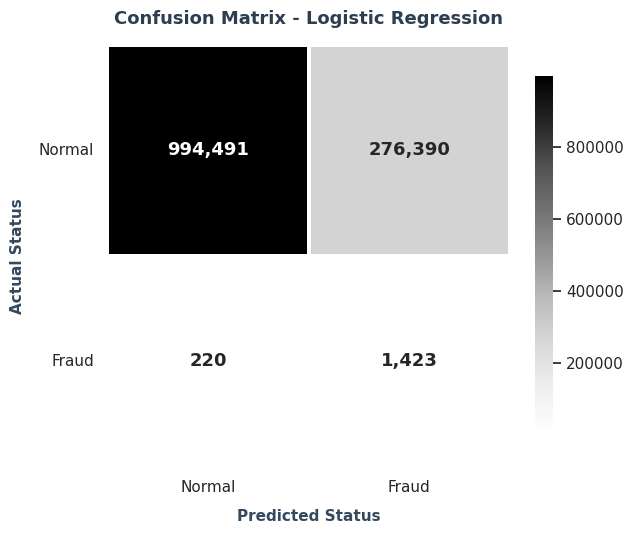

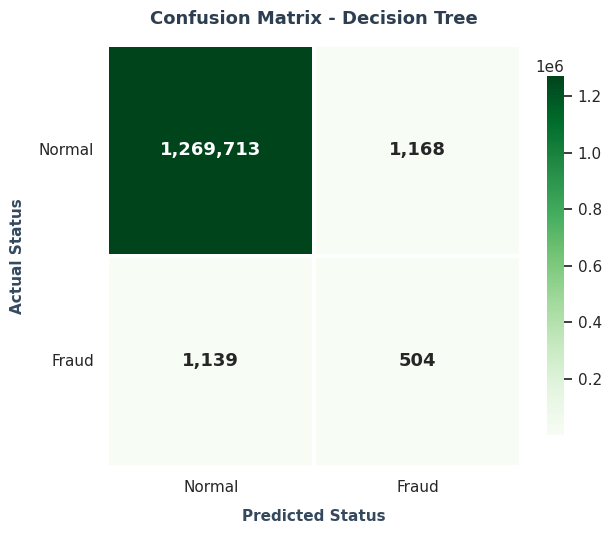

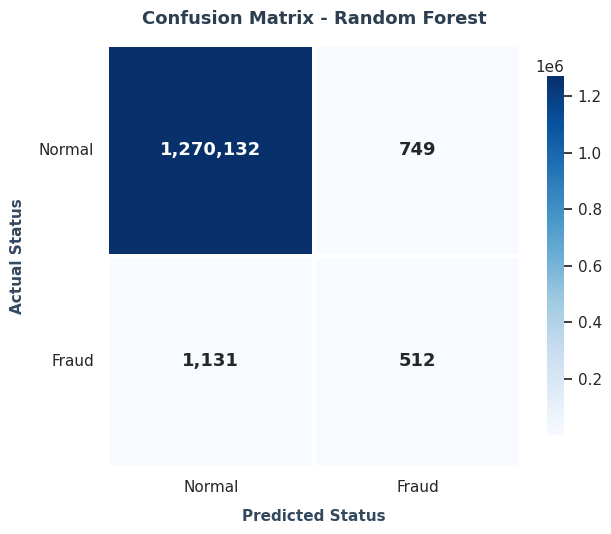

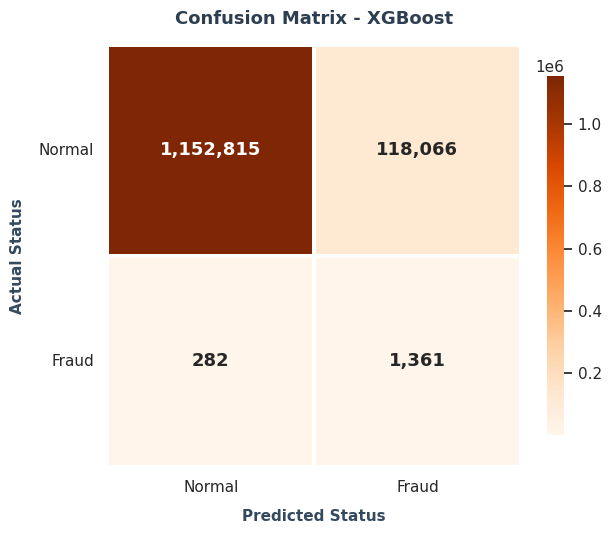

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display, HTML

sns.set_theme(style="white")

model_colors = {
    "Logistic Regression": "Greys",
    "Decision Tree": "Greens",
    "Random Forest": "Blues",
    "XGBoost": "Oranges"
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    # 1. ดึงข้อความ Classification Report ออกมา
    report_text = classification_report(y_test, y_pred, target_names=['Normal', 'Fraud'], digits=4)

    # 2. ปรับตู้ HTML: ใช้พื้นหลังมืด (#1e1e1e) และบังคับตัวอักษรสีขาวสว่าง (#ffffff) ให้ตัดกันชัดเจน
    html_output = f"""
    <div style="background-color: #1e1e1e; padding: 20px; border-radius: 8px; margin-top: 20px; border: 1px solid #334155;">
        <h4 style="color: #f97316; margin-top: 0; font-family: sans-serif; font-size: 16px;">📊 --- รายงานประเมินผล (Classification Report): {name} ---</h4>
        <pre style="font-family: 'Courier New', Courier, monospace; font-size: 14px; line-height: 1.6; color: #ffffff; background-color: transparent; border: none; margin: 0; padding: 0;">{report_text}</pre>
    </div>
    """
    display(HTML(html_output))

    # 3. คำนวณและพลอต Confusion Matrix ต่อด้านล่างทันที
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    chosen_cmap = model_colors.get(name, "Purples")

    sns.heatmap(cm, annot=True, fmt=',d', cmap=chosen_cmap, cbar=True,
                linewidths=1.5, linecolor='white',
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'],
                annot_kws={"size": 13, "weight": "bold"},
                cbar_kws={'shrink': 0.85})

    ax.set_title(f"Confusion Matrix - {name}", fontsize=13, fontweight='bold', pad=15, color='#2c3e50')
    ax.set_ylabel("Actual Status", fontsize=11, fontweight='bold', labelpad=10, color='#34495e')
    ax.set_xlabel("Predicted Status", fontsize=11, fontweight='bold', labelpad=10, color='#34495e')

    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11, rotation=0)
    plt.tight_layout()

    safe_name = name.lower().replace(" ", "_")
    plt.savefig(f"/content/drive/MyDrive/cm_report_{safe_name}_fixed.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n" + "="*80 + "\n")

# ดูโครงสร้างข้อมูล

In [ ]:
# ดูประเภทข้อมูลและจำนวนช่องว่าง (Missing Values) ในแต่ละคอลัมน์
print("--- โครงสร้างของข้อมูล (Data Info) ---")
df.info()

print("\n" + "="*50 + "\n")

# ดูสถิติเชิงพรรณนา (ค่าเฉลี่ย, มิน-แมกซ์, ตัวเลขสรุปภาพรวม) ของคอลัมน์ตัวเลขทั้งหมด
print("--- สถิติภาพรวมของข้อมูล (Data Description) ---")
df.describe()

--- โครงสร้างของข้อมูล (Data Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 14 columns):
 #   Column            Dtype  
---  ------            -----  
 0   step              int64  
 1   type              object 
 2   amount            float64
 3   nameOrig          object 
 4   oldbalanceOrg     float64
 5   newbalanceOrig    float64
 6   nameDest          object 
 7   oldbalanceDest    float64
 8   newbalanceDest    float64
 9   isFraud           int64  
 10  isFlaggedFraud    int64  
 11  hour_of_day       int64  
 12  day_of_week       int64  
 13  is_dest_merchant  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 679.6+ MB


--- สถิติภาพรวมของข้อมูล (Data Description) ---


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour_of_day,day_of_week,is_dest_merchant
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06,1.532145e+01,3.481576e+00,3.381461e-01
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03,4.321799e+00,2.165331e+00,4.730786e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.200000e+01,2.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00,1.600000e+01,3.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00,1.900000e+01,6.000000e+00,1.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00,2.300000e+01,7.000000e+00,1.000000e+00


In [ ]:
# ส่องดูข้อมูล 10 แถวแรกสุดของไฟล์
#df.head(10)

# ส่องดูข้อมูล 10 แถวท้ายสุดของไฟล์
df.tail(10)

# สุ่ม (Random) แถวตรงไหนก็ได้ในไฟล์มาดู 10 แถวเพื่อเช็กความหลากหลาย
#df.sample(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour_of_day,day_of_week,is_dest_merchant
6362610,742,TRANSFER,63416.99,C778071008,63416.99,0.0,C1812552860,0.00,0.00,1,0,22,3,0
6362611,742,CASH_OUT,63416.99,C994950684,63416.99,0.0,C1662241365,276433.18,339850.17,1,0,22,3,0
6362612,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.0,C1470998563,0.00,0.00,1,0,23,3,0
6362613,743,CASH_OUT,1258818.82,C1436118706,1258818.82,0.0,C1240760502,503464.50,1762283.33,1,0,23,3,0
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.0,C1850423904,0.00,0.00,1,0,23,3,0
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,23,3,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,23,3,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,23,3,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,23,3,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0,23,3,0


In [ ]:
# ดึงเฉพาะธุรกรรมที่เป็นเคสทุจริต (isFraud เป็น 1) มาโชว์ดู 5 แถวแรก
fraud_cases = df[df['isFraud'] == 1]
print(f"จำนวนเคสโกงทั้งหมดที่ตรวจพบในไฟล์: {fraud_cases.shape[0]:,} แถว")
fraud_cases.head(8213)

จำนวนเคสโกงทั้งหมดที่ตรวจพบในไฟล์: 8,213 แถว


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour_of_day,day_of_week,is_dest_merchant
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,1,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,1,1,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1,0,1,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,0,1,1,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,23,3,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,23,3,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,23,3,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,23,3,0
